In [41]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import folium
import matplotlib.colors as mcolors
import os, webbrowser
import osmnx as ox
import plotly.express as px
import plotly.graph_objects as go

![Solum](img/logosolum-1024x288.png)

-------------------------------------------------------------------------------------------------------------------------------------------

### **HECHO SOBRE rome_clean.csv *(dataset limpio del EDA)***

In [2]:
csv_path = Path("../data/processed/rome_clean.csv")
df = pd.read_csv(csv_path)
df.head()


,idS,tsO,tsD,price,tt,dis,vel,lonO,latO,lonD,latD,duration_calc
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,2.1525,461,1715.336751,13.395254,12.466222,41.867388,12.470660,41.853908,461.0
1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,1.6500,260,1234.472044,17.092690,12.471143,41.923692,12.467502,41.934306,260.0
2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,2.2225,489,2221.481536,16.354465,12.467524,41.934342,12.486330,41.928270,489.0
3,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,4.0000,1200,4562.843566,13.688531,12.486275,41.928301,12.457922,41.904302,1200.0
4,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,1.5025,201,550.154792,9.853519,12.457876,41.904303,12.460773,41.907606,201.0


# **1.- Costes iniciales de despliegue**

### [[Archivo en Drive]](https://docs.google.com/spreadsheets/d/13ahkFnmJFy9O9baVh072Jt27tcLlAUzzjXE-qM_GXCA/edit?usp=sharing)


# **2.- Costes Operativos**

### [[Archivo en Drive]](https://docs.google.com/spreadsheets/d/13ahkFnmJFy9O9baVh072Jt27tcLlAUzzjXE-qM_GXCA/edit?usp=sharing)


--------------------------------------------------------------------------------------------------------------------------------------------

# **3.- Ingresos - Modelo de Negocio**

### 1.1) Suma del precio recaudado en todos los viajes en Roma en Febrero 2021

In [3]:
total_price = df['price'].sum()
print(total_price)

63208.36749999999


### 1.2) Precio por viaje (recogido en `metrics.ipynb`)

**- Precio fijo: 1 €**

**- Precio variable por minuto: 0.15 €**

### 1.3) Número de viajes por día e ingresos diarios

In [4]:

df['tsO'] = pd.to_datetime(df['tsO'])


df['date'] = df['tsO'].dt.date
viajes_por_dia = df.groupby('date').size().reset_index(name='num_viajes')
print(viajes_por_dia)

          date  num_viajes
0   2021-02-01         703
1   2021-02-02         767
2   2021-02-03         813
3   2021-02-04         806
4   2021-02-05         884
5   2021-02-06        1004
6   2021-02-07         407
7   2021-02-08         684
8   2021-02-09         728
9   2021-02-10         680
10  2021-02-11         828
11  2021-02-12         910
12  2021-02-13         718
13  2021-02-14         745
14  2021-02-15         748
15  2021-02-16         743
16  2021-02-17         842
17  2021-02-18         984
18  2021-02-19         997
19  2021-02-20        1069
20  2021-02-21         904
21  2021-02-22         881
22  2021-02-23         877
23  2021-02-24         921
24  2021-02-25        1007
25  2021-02-26        1101
26  2021-02-27        1038
27  2021-02-28         853


In [5]:
ingresos_diarios = df.groupby('date')['price'].sum()
print(ingresos_diarios)

date
2021-02-01    1744.6650
2021-02-02    1946.7625
2021-02-03    2057.3350
2021-02-04    2039.7375
2021-02-05    2489.4550
2021-02-06    2881.6000
2021-02-07    1129.7400
2021-02-08    1842.4300
2021-02-09    1893.7150
2021-02-10    1635.7350
2021-02-11    2182.2800
2021-02-12    2472.4825
2021-02-13    1952.0150
2021-02-14    2107.4425
2021-02-15    1930.2825
2021-02-16    1928.0950
2021-02-17    2170.0450
2021-02-18    2514.3500
2021-02-19    2543.7875
2021-02-20    2935.4850
2021-02-21    2614.5100
2021-02-22    2418.5975
2021-02-23    2311.2975
2021-02-24    2421.7475
2021-02-25    2697.1800
2021-02-26    2810.5625
2021-02-27    3030.1400
2021-02-28    2506.8925
Name: price, dtype: float64


### 1.4) Viajes más rentables según la distancia recorrida

In [6]:
df['tipo_viaje'] = pd.cut(
    df['dis'],
    bins=[0, 2500, 5000, float('inf')],
    labels=['corto', 'medio', 'largo'],
    include_lowest=True
)

In [7]:
df['tipo_viaje'].value_counts()

tipo_viaje
corto    16618
medio     5630
largo     1394
Name: count, dtype: int64

In [8]:
precio_por_tipo = df.groupby('tipo_viaje')['price'].mean()
print(precio_por_tipo)


tipo_viaje
corto    2.063855
medio    3.685373
largo    5.855511
Name: price, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11020\2274296304.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precio_por_tipo = df.groupby('tipo_viaje')['price'].mean()


In [9]:
resultados = df.groupby('tipo_viaje')['price'].agg(
    num_viajes='count',
    ingresos_totales='sum',
    ingreso_medio='mean'
).reset_index()

print(resultados)

  tipo_viaje  num_viajes  ingresos_totales  ingreso_medio
0      corto       16618        34297.1350       2.063855
1      medio        5630        20748.6500       3.685373
2      largo        1394         8162.5825       5.855511


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11020\3904734918.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultados = df.groupby('tipo_viaje')['price'].agg(


### 1.5) Análisis por cuadrículas de zonas que más ingresos generan

- 1.5.1) Descragamos forma de Roma y generamos una cuadrícula de 500m

In [10]:
roma = ox.geocode_to_gdf("Rome, Italy")
roma_utm = roma.to_crs(epsg=32633)

minx, miny, maxx, maxy = roma_utm.total_bounds
grid_size = 500

x_range = np.arange(minx, maxx, grid_size)
y_range = np.arange(miny, maxy, grid_size)

polygons = [
    Polygon([(x, y), (x+grid_size, y), (x+grid_size, y+grid_size), (x, y+grid_size)])
    for x in x_range for y in y_range
]

grid = gpd.GeoDataFrame({'geometry': polygons}, crs=roma_utm.crs)
grid = gpd.overlay(grid, roma_utm, how='intersection')

- 1.5.2) Convertimos de Dataframe a GeoDataframe

In [11]:
df['geometry'] = df.apply(lambda r: Point(r['lonO'], r['latO']), axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326").to_crs(roma_utm.crs)

- 1.5.3) Asignamos cada viaje a una cuadrícula

In [12]:
joined = gpd.sjoin(gdf, grid, how='left', predicate='within')

- 1.5.4) Sumamos ingresos por cuadrícula

In [13]:
income = joined.groupby("index_right")["price"].sum().reset_index()
income.columns = ["cell_id", "total_income"]

income_grid = grid.reset_index().merge(
    income, left_index=True, right_on="cell_id", how="left"
).fillna({"total_income": 0})

# Convertir a WGS para Folium
income_grid_wgs = income_grid.to_crs(epsg=4326)

- 1.5.5) Mostramos las 10 cuadrículas con mayores ingresos

In [14]:
top10 = income_grid_wgs.sort_values("total_income", ascending=False).head(10)
print("\n========== TOP 10 CUADRÍCULAS POR INGRESOS ==========\n")
print(top10[["cell_id", "total_income"]])


========== TOP 10 CUADRÍCULAS POR INGRESOS ==========

       cell_id  total_income
250.0   3679.0     1247.4350
235.0   3596.0     1131.0375
39.0    2832.0     1107.0850
132.0   3089.0     1087.6625
221.0   3512.0     1080.7675
212.0   3431.0     1025.3650
96.0    3001.0     1020.1275
143.0   3157.0      963.4825
192.0   3341.0      868.9350
128.0   3085.0      842.7125


- 1.5.6) Mostramos Mapa

In [15]:
min_price = income_grid_wgs["total_income"].min()
max_price = income_grid_wgs["total_income"].max()

cmap = mcolors.LinearSegmentedColormap.from_list("", ["#fff5eb", "#7f0000"])

def style(feature):
    p = feature["properties"]["total_income"]
    norm = (p - min_price) / (max_price - min_price + 1e-9)
    return {
        "fillColor": mcolors.to_hex(cmap(norm)),
        "color": "grey",
        "weight": 0.2,
        "fillOpacity": 0.8
    }

m = folium.Map(location=[41.90, 12.50], zoom_start=12, tiles="cartodbpositron")

tooltip = folium.GeoJsonTooltip(
    fields=["cell_id", "total_income"],
    aliases=["Celda:", "Ingresos (€):"],
    localize=True
)

folium.GeoJson(
    income_grid_wgs,
    style_function=style,
    tooltip=tooltip
).add_to(m)

output = os.path.abspath("files/mapa_ingresos_roma.html")
m.save(output)
webbrowser.open(f"file://{output}")

print("\nMapa guardado y abierto en el navegador:", output)


Mapa guardado y abierto en el navegador: c:\Users\Lenovo\OneDrive - Universidad Politécnica de Madrid\SERGIO2025_2026\Github\mobility-optimization\costs\files\mapa_ingresos_roma.html


---------------------------------------------------------------------------------------------------------------------------------------------

### **Análisis de ingresos a partir de otro conjunto de datos (proporcionalidad mes a mes)**

Para extrapolar la demanda anual, pensamos en utilizar el dataset oficial de Bicimad (Madrid), que publica viajes mensuales reales y presenta un patrón estacional comparable al esperado en Roma, dado su clima mediterráneo, densidad urbana similar y volumen turístico. Debido a la complejidad en la que estaban recogidos los datos, y que encontramos una solución que se consideró más plausible, desechamos esta idea para esta tarea concreta. (No la descartamos para futuros análisis)

*Adjunto enlace*: [text](https://datos.madrid.es/portal/site/egob/menuitem.c05c1f754a33a9fbe4b2e4b284f1a5a0/?vgnextoid=54e76af6a185a910VgnVCM200000f921e388RCRD&vgnextchannel=374512b9ace9f310VgnVCM100000171f5a0aRCRD&vgnextfmt=default)

Para hacer una estimación anual, hemos decidido coger un dataset de micromobilidad, recabado en el año 2021, en Austin, Texas: [text](https://data.austintexas.gov/Transportation-and-Mobility/Shared-Micromobility-Vehicle-Trips-2018-2022-/7d8e-dm7r/about_data)

![Texas](img/open-data-logo.png)

Aunque las condiciones de densidad de población y geográfica no sean las mimas, las tendencias son muy similares, por lo que puede ser una buena forma de estimar los ingresos mes a mes con otra ciudad de referencia. Además sumar la dificulatd de encontrar datasets que se parezcan lo máximo posible a nuestro caso.

**IMPORTANTE: Para este análsis de ingresos, sólo vamos a tener en cuenta los ingresos directos. No se van a tener en cuenta, que podría ser una opción a futuro planes de suscripción que podrían fomentar el uso repetido y nos crearía un flujo de ingresos más constante**

### Viusalización de su estructura

In [16]:
df = pd.read_csv(
    "files/austin-metrics-data-for-scooter.csv",
    engine="python",
    index_col=False
)
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11020\335276755.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(


,Time Period,Median Trip Distance (kilometers),Median Trip Duration (minutes),Average Trip Distance (kilometers),Average Trip Duration (minutes),Average Trips per Day,Total Distance (kilometers),Total MDS Trips
0,all,0.0,7.6,15127.83,11.9,8194,37265648,20199200
1,2019-Q1,0.0,7.8,19312.13,13.7,12072,1735034,1086500
2,2019-Q2,0.0,7.7,26393.24,13.0,15557,2398566,1415700
3,2019-Q3,0.0,7.3,28002.59,11.8,14715,2575916,1353800
4,2019-Q4,0.0,7.0,19312.13,11.2,11215,1771888,1031800


### Ligera limpieza para mejor análisis

In [17]:
df = df.dropna(axis=1, how="all")

In [18]:
df.head()
df.columns

Index(['Time Period', 'Median Trip Distance (kilometers)',
       'Median Trip Duration (minutes)', 'Average Trip Distance (kilometers)',
       'Average Trip Duration (minutes)', 'Average Trips per Day',
       'Total Distance (kilometers)', 'Total MDS Trips'],
      dtype='object')

In [19]:
df['Time Period'].unique()
df = df[df["Time Period"] != "all"]

In [20]:
df_2021 = df[df["Time Period"].str.startswith("2021")]
df_2021

,Time Period,Median Trip Distance (kilometers),Median Trip Duration (minutes),Average Trip Distance (kilometers),Average Trip Duration (minutes),Average Trips per Day,Total Distance (kilometers),Total MDS Trips
9,2021-Q1,0.0,9.1,11587.28,14.6,4538,1036257,408400
10,2021-Q2,0.0,9.1,22208.95,14.1,10380,2022624,944600
11,2021-Q3,0.0,8.5,21726.14,12.8,11530,2005886,1060800
12,2021-Q4,0.0,8.4,18829.32,12.3,9760,1734712,897900


In [21]:
df_2021["Date"] = pd.PeriodIndex(df_2021["Time Period"], freq="Q").to_timestamp()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11020\1784735725.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2021["Date"] = pd.PeriodIndex(df_2021["Time Period"], freq="Q").to_timestamp()


### Datos recogido de forma trimestral, por lo que desglosamos mes a mes (mismos datos de 3 en 3 meses)

In [22]:
monthly_rows = []

for _, row in df_2021.iterrows():
    period = row["Time Period"]
    year, quarter = period.split("-")

    if quarter == "Q1":
        months = ["01", "02", "03"]
    elif quarter == "Q2":
        months = ["04", "05", "06"]
    elif quarter == "Q3":
        months = ["07", "08", "09"]
    else:
        months = ["10", "11", "12"]

    for m in months:
        monthly_rows.append({
            "month": f"{year}-{m}",
            "avg_trips_per_day": row["Average Trips per Day"],
            "total_mds_trips": row["Total MDS Trips"]
        })

monthly_df = pd.DataFrame(monthly_rows)
monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df


,month,avg_trips_per_day,total_mds_trips
0,2021-01-01,4538,408400
1,2021-02-01,4538,408400
2,2021-03-01,4538,408400
3,2021-04-01,10380,944600
4,2021-05-01,10380,944600
5,2021-06-01,10380,944600
6,2021-07-01,11530,1060800
7,2021-08-01,11530,1060800
8,2021-09-01,11530,1060800
9,2021-10-01,9760,897900


### Cáluclo de la proporción (lo que realmente nos interesa)

In [23]:
monthly_df["season_factor"] = monthly_df["avg_trips_per_day"] / monthly_df["avg_trips_per_day"].mean()
monthly_df


,month,avg_trips_per_day,total_mds_trips,season_factor
0,2021-01-01,4538,408400,0.501326
1,2021-02-01,4538,408400,0.501326
2,2021-03-01,4538,408400,0.501326
3,2021-04-01,10380,944600,1.146708
4,2021-05-01,10380,944600,1.146708
5,2021-06-01,10380,944600,1.146708
6,2021-07-01,11530,1060800,1.273752
7,2021-08-01,11530,1060800,1.273752
8,2021-09-01,11530,1060800,1.273752
9,2021-10-01,9760,897900,1.078215


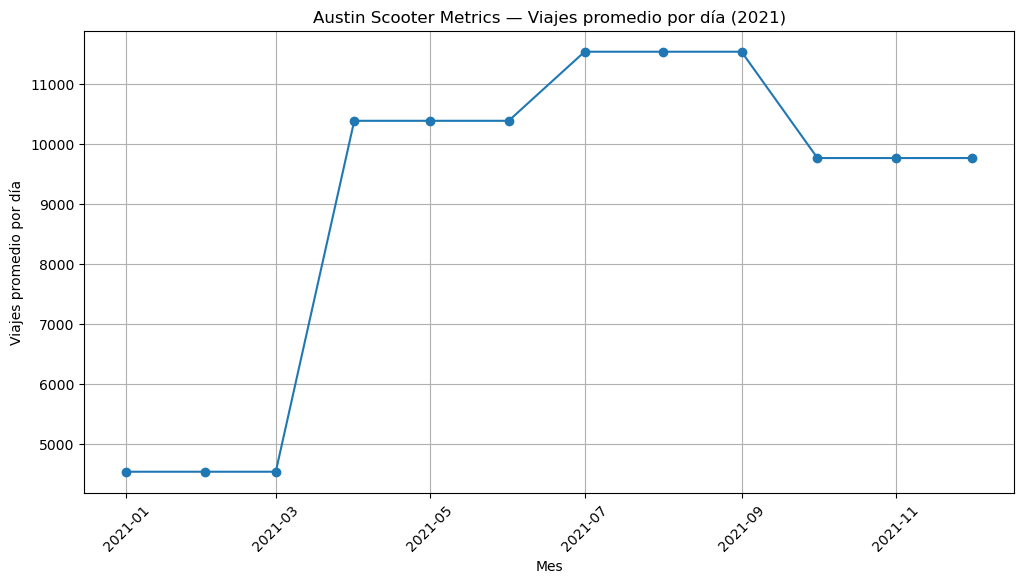

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_df["month"], monthly_df["avg_trips_per_day"], marker="o")
plt.grid(True)
plt.title("Austin Scooter Metrics — Viajes promedio por día (2021)")
plt.xlabel("Mes")
plt.ylabel("Viajes promedio por día")
plt.xticks(rotation=45)
plt.show()

### Extrapolamos a nivel anual

In [25]:
# Mis datos
ingreso_feb = 63208.3675
ingreso_dia = ingreso_feb / 28
factor_feb = 0.501326

ingreso_base = ingreso_dia / factor_feb


monthly_df["days"] = monthly_df["month"].dt.days_in_month
monthly_df["estimated_income"] = monthly_df["season_factor"] * ingreso_base * monthly_df["days"]

monthly_df[["month", "season_factor", "days", "estimated_income"]]

,month,season_factor,days,estimated_income
0,2021-01-01,0.501326,31,69980.647066
1,2021-02-01,0.501326,28,63208.326383
2,2021-03-01,0.501326,31,69980.647066
3,2021-04-01,1.146708,30,154906.762226
4,2021-05-01,1.146708,31,160070.320967
5,2021-06-01,1.146708,30,154906.762226
6,2021-07-01,1.273752,31,177804.508743
7,2021-08-01,1.273752,31,177804.508743
8,2021-09-01,1.273752,30,172068.879429
9,2021-10-01,1.078215,31,150509.280601


In [26]:
import plotly.express as px

total_income = monthly_df["estimated_income"].sum()
print("Ingreso anual estimado:", round(total_income, 2))

fig = px.line(
    monthly_df,
    x="month",
    y="estimated_income",
    markers=True,
    title="Ingresos Estimados por Mes (Roma 2021 ajustado con estacionalidad real)",
    labels={"estimated_income": "Ingresos (€)", "month": "Mes"},
    template="plotly_dark" 
)

fig.show()

monthly_df

Ingreso anual estimado: 1647404.07


,month,avg_trips_per_day,total_mds_trips,season_factor,days,estimated_income
0,2021-01-01,4538,408400,0.501326,31,69980.647066
1,2021-02-01,4538,408400,0.501326,28,63208.326383
2,2021-03-01,4538,408400,0.501326,31,69980.647066
3,2021-04-01,10380,944600,1.146708,30,154906.762226
4,2021-05-01,10380,944600,1.146708,31,160070.320967
5,2021-06-01,10380,944600,1.146708,30,154906.762226
6,2021-07-01,11530,1060800,1.273752,31,177804.508743
7,2021-08-01,11530,1060800,1.273752,31,177804.508743
8,2021-09-01,11530,1060800,1.273752,30,172068.879429
9,2021-10-01,9760,897900,1.078215,31,150509.280601


Recalcar que son datos lo más aproximados posibles, pero que obviamente no van a ser los reales. Aún así se acerca mucho a lo que nuestra intuición creía.

Notar repuntes desde abril a septiembre (meses de mayor afluencia)

------------------------------------------------------------------------------------------------------------------------------------------------

### **Factor Turismo** *(escensario optimista)*

![Tourism](img/ancient-amphitheater-roman-architecture-historic-landmark-stone-structure-travel-destination-cultural-heritage-famous-build.png)

Factor tursimo escogido de forma aprox, de momento no se ha elegido ninguna evidencia respaldad por datos reales.

In [27]:
monthly_df["tourism_factor"] = [
    1.00, 1.00, 1.00,  # Ene–Mar
    1.25, 1.30, 1.35,  # Abr–Jun
    1.40, 1.20, 1.35,  # Jul–Sep
    1.05, 1.05, 1.05   # Oct–Dic
]

monthly_df["final_income"] = (
    monthly_df["estimated_income"]
    * monthly_df["tourism_factor"]
)

In [28]:
fig = px.line(
    monthly_df,
    x="month",
    y=["estimated_income", "final_income"],
    title="Comparativa de Ingresos: Estacionalidad vs Ajuste por Turismo (Roma)",
    labels={"value": "Ingresos (€)", "month": "Mes"},
    markers=True
)

fig.update_layout(
    legend_title="Tipo de ingreso",
    xaxis_title="Mes",
    yaxis_title="Ingresos (€)",
    template="plotly_dark" 
)

fig.show()

In [29]:
ingreso_anual_esperado = monthly_df["final_income"].sum()

print(" INGRESO ANUAL ESPERADO (ROMA 2021)")
print(" Ajustado por la diferencia del turismo entre Texas y Roma")
print("------------------------------------------------")

print(f"Total estimado: {ingreso_anual_esperado:,.2f} €")
print("------------------------------------------------\n")

monthly_df_display = monthly_df[["month", "estimated_income", "tourism_factor", "final_income"]]
monthly_df_display

 INGRESO ANUAL ESPERADO (ROMA 2021)
 Ajustado por la diferencia del turismo entre Texas y Roma
------------------------------------------------
Total estimado: 1,977,609.67 €
------------------------------------------------



,month,estimated_income,tourism_factor,final_income
0,2021-01-01,69980.647066,1.00,69980.647066
1,2021-02-01,63208.326383,1.00,63208.326383
2,2021-03-01,69980.647066,1.00,69980.647066
3,2021-04-01,154906.762226,1.25,193633.452783
4,2021-05-01,160070.320967,1.30,208091.417257
5,2021-06-01,154906.762226,1.35,209124.129006
6,2021-07-01,177804.508743,1.40,248926.312240
7,2021-08-01,177804.508743,1.20,213365.410492
8,2021-09-01,172068.879429,1.35,232292.987229
9,2021-10-01,150509.280601,1.05,158034.744631


-----------------------------------------------------------------------------------------------------------------------------------------------

### **Rangos reales en la industria**

![VOI](img/voi-technology-ab.png)

- Indicador más importante: **RVD** (Revenue per Vehicle and Day)

$$
\text{RVD} = \frac{\text{Ingresos totales (€)}}{\text{Vehículos desplegados} \times \text{Días}}
$$

[[**Informe VOI. 2024**]](https://storage.mfn.se/3a2fbf55-83cf-4b2f-896e-3c5a5febe31c/voi-group-2024-annual-report.pdf)


RVD que se incluye en el informe (media países europeos):

- Ingresos netos → EUR 132.8M
- Flota de vehículos desplegados → 92,800 vehículos
- Días → 365

RVD anual = **3,91**

RVD de nuestros datos en febrero (temporada baja, datos 100% reales)

In [30]:
ingresos_feb = 63208
dias_feb = 28
patinetes = 2307

RVD_feb = ingresos_feb / (patinetes * dias_feb)
RVD_feb

0.9785126013994675

RVD de nuestros datos anuales (datos que hemos estimado)

In [31]:
ingresos_anuales = 1977609.67
dias_ano = 365
patinetes = 2307

RVD_anual = ingresos_anuales / (patinetes * dias_ano)
RVD_anual

2.3485516623023437

### **Conclusión Final**:

Para finalizar el análisis de ingresos, hemos intentado ser lo más rigurosos posibles en la estimación y validación de los valores obtenidos. Con el fin de comprobar que nuestros resultados no eran ni excesivamente altos ni demasiado bajos, realizamos una comparación con datos reales de un operador líder de micromovilidad en Europa: VOI Technology. Esta empresa tiene publicados unos informes de sus datos en 2024 y 2023.

La métrica utilizada para esta comparación es el RVD *(Revenue per Vehicle and Day)*, ampliamente empleada por ayuntamientos y empresas del sector para evaluar la rentabilidad y viabilidad de proyectos de micromovilidad. Se trata de un indicador que relaciona los ingresos generados con el tamaño de la flota de vehículos y el tiempo de operación.

Es importante señalar que VOI publica sus RVD correspondientes a los años 2023 y 2024, con tendencia claramente creciente (cada año aumenta). Este incremento anual refleja el crecimiento del sector de los e-scooters. Por ello, resulta razonable asumir que los datos obtenidos en nuestro análisis basados en febrero de 2021, un año de recuperación post-pandemia y con tarifas inferiores a las actuales, representan una estimación conservadora respecto al contexto actual.

Nuestros resultados muestran:

- RVD estimado (Roma, 2021): 2,34 €/vehículo/día

- RVD de VOI (Europa, 2024): 3,91 €/vehículo/día

La diferencia entre ambos valores sugiere que nuestros ingresos anuales proyectados son prudentes y realistas, situándose claramente por debajo de la media europea actual. Esto confirma que nuestro modelo no sobreestima la rentabilidad del servicio, sino que proporciona una base sólida sobre la que construir escenarios futuros más ajustados al crecimiento del sector.

------------------------------------------------------------------------------------------------------------------------------------------

### **Con los nuevos datos post-clusterización**

In [32]:
# Mis datos
ingreso_feb = 55062
ingreso_dia = ingreso_feb / 28
factor_feb = 0.501326

ingreso_base = ingreso_dia / factor_feb


monthly_df["days"] = monthly_df["month"].dt.days_in_month
monthly_df["estimated_income"] = monthly_df["season_factor"] * ingreso_base * monthly_df["days"]

monthly_df[["month", "season_factor", "days", "estimated_income"]]

,month,season_factor,days,estimated_income
0,2021-01-01,0.501326,31,60961.460344
1,2021-02-01,0.501326,28,55061.964182
2,2021-03-01,0.501326,31,60961.460344
3,2021-04-01,1.146708,30,134942.199570
4,2021-05-01,1.146708,31,139440.272889
5,2021-06-01,1.146708,30,134942.199570
6,2021-07-01,1.273752,31,154888.858036
7,2021-08-01,1.273752,31,154888.858036
8,2021-09-01,1.273752,30,149892.443261
9,2021-10-01,1.078215,31,131111.470463


In [33]:
import plotly.express as px

total_income = monthly_df["estimated_income"].sum()
print("Ingreso anual estimado:", round(total_income, 2))

fig = px.line(
    monthly_df,
    x="month",
    y="estimated_income",
    markers=True,
    title="Ingresos Estimados por Mes (Roma 2021 ajustado con estacionalidad real)",
    labels={"estimated_income": "Ingresos (€)", "month": "Mes"},
    template="plotly_dark" 
)

fig.show()

monthly_df

Ingreso anual estimado: 1435084.73


,month,avg_trips_per_day,total_mds_trips,season_factor,days,estimated_income,tourism_factor,final_income
0,2021-01-01,4538,408400,0.501326,31,60961.460344,1.00,69980.647066
1,2021-02-01,4538,408400,0.501326,28,55061.964182,1.00,63208.326383
2,2021-03-01,4538,408400,0.501326,31,60961.460344,1.00,69980.647066
3,2021-04-01,10380,944600,1.146708,30,134942.199570,1.25,193633.452783
4,2021-05-01,10380,944600,1.146708,31,139440.272889,1.30,208091.417257
5,2021-06-01,10380,944600,1.146708,30,134942.199570,1.35,209124.129006
6,2021-07-01,11530,1060800,1.273752,31,154888.858036,1.40,248926.312240
7,2021-08-01,11530,1060800,1.273752,31,154888.858036,1.20,213365.410492
8,2021-09-01,11530,1060800,1.273752,30,149892.443261,1.35,232292.987229
9,2021-10-01,9760,897900,1.078215,31,131111.470463,1.05,158034.744631


In [34]:
monthly_df["tourism_factor"] = [
    1.00, 1.00, 1.00,  # Ene–Mar
    1.25, 1.30, 1.35,  # Abr–Jun
    1.40, 1.20, 1.35,  # Jul–Sep
    1.05, 1.05, 1.05   # Oct–Dic
]

monthly_df["final_income"] = (
    monthly_df["estimated_income"]
    * monthly_df["tourism_factor"]
)

ingreso_anual_esperado = monthly_df["final_income"].sum()

print(" INGRESO ANUAL ESPERADO (ROMA 2021)")
print(" Ajustado por la diferencia del turismo entre Texas y Roma")
print("------------------------------------------------")

print(f"Total estimado: {ingreso_anual_esperado:,.2f} €")
print("------------------------------------------------\n")

monthly_df_display = monthly_df[["month", "estimated_income", "tourism_factor", "final_income"]]
monthly_df_display

 INGRESO ANUAL ESPERADO (ROMA 2021)
 Ajustado por la diferencia del turismo entre Texas y Roma
------------------------------------------------
Total estimado: 1,722,733.05 €
------------------------------------------------



,month,estimated_income,tourism_factor,final_income
0,2021-01-01,60961.460344,1.00,60961.460344
1,2021-02-01,55061.964182,1.00,55061.964182
2,2021-03-01,60961.460344,1.00,60961.460344
3,2021-04-01,134942.199570,1.25,168677.749463
4,2021-05-01,139440.272889,1.30,181272.354756
5,2021-06-01,134942.199570,1.35,182171.969420
6,2021-07-01,154888.858036,1.40,216844.401251
7,2021-08-01,154888.858036,1.20,185866.629643
8,2021-09-01,149892.443261,1.35,202354.798402
9,2021-10-01,131111.470463,1.05,137667.043986


### **Tabla comparativa**

|  | Ingresos Febrero (€) | Ingresos Totales (€) |
|-----|--------|--------------|
Después del EDA| 63208,367 € | 1.977.609,67 € |  |
Después Clusterización| 55062 € | 1,722,733.05 € |  |
Diferencia | 8146,367 € | 254876,62 € |


In [ ]:
ingresos_eda_total = 1_977_609.67
ingresos_cluster_total = 1_722_733.05
perdida_total = ingresos_eda_total - ingresos_cluster_total
porcentaje_perdida = (perdida_total / ingresos_eda_total) * 100

labels = ["Ingresos Conservados", "Pérdida"]
values = [ingresos_cluster_total, perdida_total]

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.35,
    textinfo="label+percent",
    hovertemplate="<b>%{label}</b><br>%{value:,.2f} €<br>%{percent}",
    marker=dict(
        colors=["#4A6CF7", "#D84A38"],
        line=dict(color="white", width=2)
    )
)])

fig.update_layout(
    title=f"Pérdida Total: {porcentaje_perdida:.2f}%",
    paper_bgcolor="#4a4a4a",
    plot_bgcolor="#4a4a4a",
    font_color="white"
)

fig.update_traces(rotation=30, pull=[0, 0.05])

fig.show()